In [1]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

import ot
import numpy as np

In [2]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training

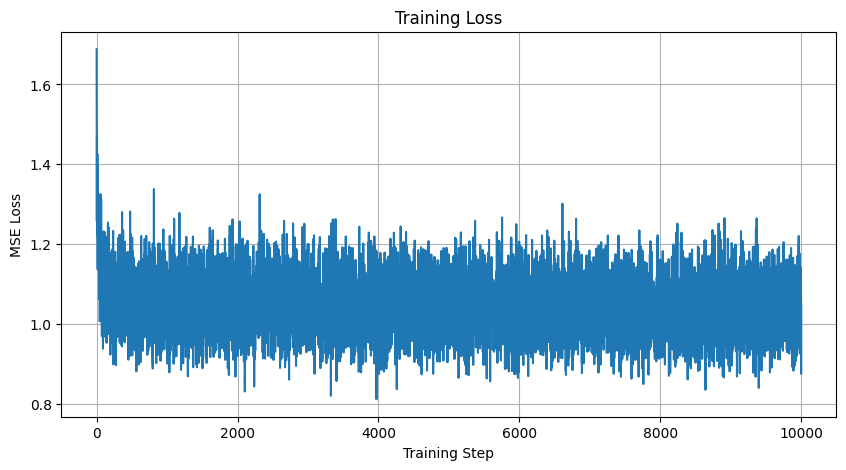

In [4]:
# GPU training
flow = Flow().to(device)

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()
losses = []

for _ in range(10000):
    x_1 = torch.tensor(make_moons(256, noise=0.15)[0], dtype=torch.float32).to(device)
    x_0 = torch.randn_like(x_1).to(device)
    t   = torch.rand(len(x_1), 1).to(device)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Training Step')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# Sampling

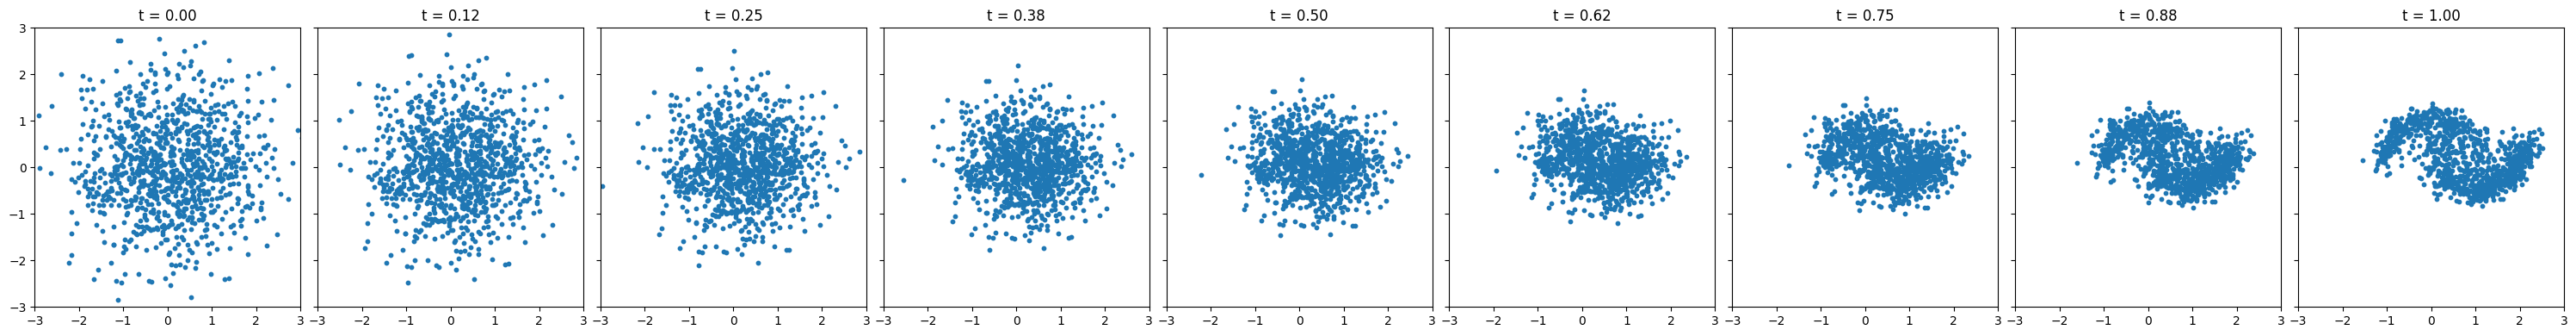

Flow 模型 Wasserstein-2 距离: 0.421585


In [8]:
x = torch.randn(1000, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

# CPU sampling
flow.cpu()

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

real_data = make_moons(1000, noise=0.15)[0]          # 返回的是 numpy array
x_np = x.detach().cpu().numpy()                      # 转为 numpy

a = np.ones(1000) / 1000
b = np.ones(1000) / 1000

w2 = np.sqrt(ot.emd2(a, b, ot.dist(real_data, x_np, metric='euclidean')))
print(f"Flow 模型 Wasserstein-2 距离: {w2:.6f}")

# Mean_Field

In [9]:
class MeanFieldFlow(nn.Module):
    def __init__(self, dim=2, h=64, stat_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim+1+stat_dim, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    def forward(self, t, x_t, stats):
        return self.net(torch.cat((t, x_t, stats), -1))
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor, stats: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start, stats=stats) * (t_end - t_start) / 2, stats=stats)

def compute_stats(x):
    mean = x.mean(0)
    var = x.var(0, unbiased=False)
    return torch.cat([mean, var])

# Mean_Field Training

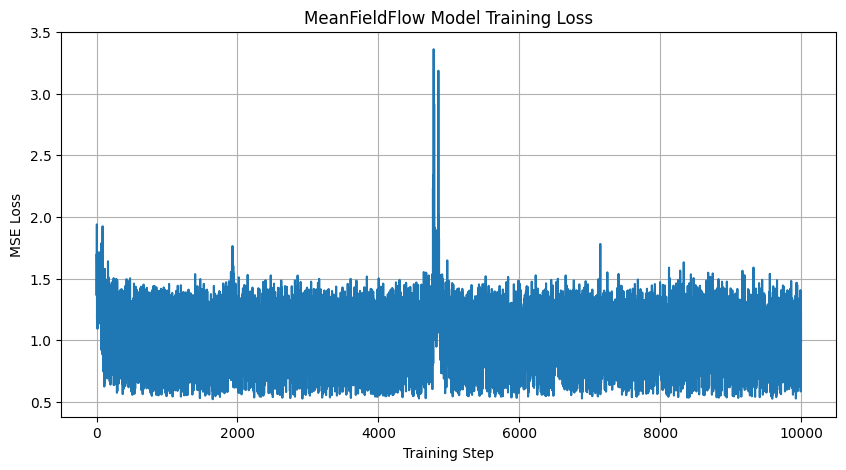

In [10]:
# GPU training
mf_flow = MeanFieldFlow().to(device)

mf_optimizer = torch.optim.Adam(mf_flow.parameters(), 1e-2)
mf_loss_fn = nn.MSELoss()
mf_losses = []

for _ in range(10000):
    x_1 = torch.tensor(make_moons(256, noise=0.15)[0], dtype=torch.float32).to(device)
    x_0 = torch.randn_like(x_1).to(device)
    # whole batch need a same t
    t = torch.rand(1, 1).expand(x_1.size(0), 1).to(device)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    # calculate stats
    stats = compute_stats(x_t)
    stats_batch = stats.unsqueeze(0).expand(x_t.size(0), -1)
    
    mf_optimizer.zero_grad()
    loss = mf_loss_fn(mf_flow(t=t, x_t=x_t,  stats=stats_batch), dx_t)
    loss.backward()
    mf_optimizer.step()

    mf_losses.append(loss.item())

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(mf_losses)
plt.xlabel('Training Step')
plt.ylabel('MSE Loss')
plt.title('MeanFieldFlow Model Training Loss')
plt.grid(True)
plt.show()

# Mean_Field Sampling

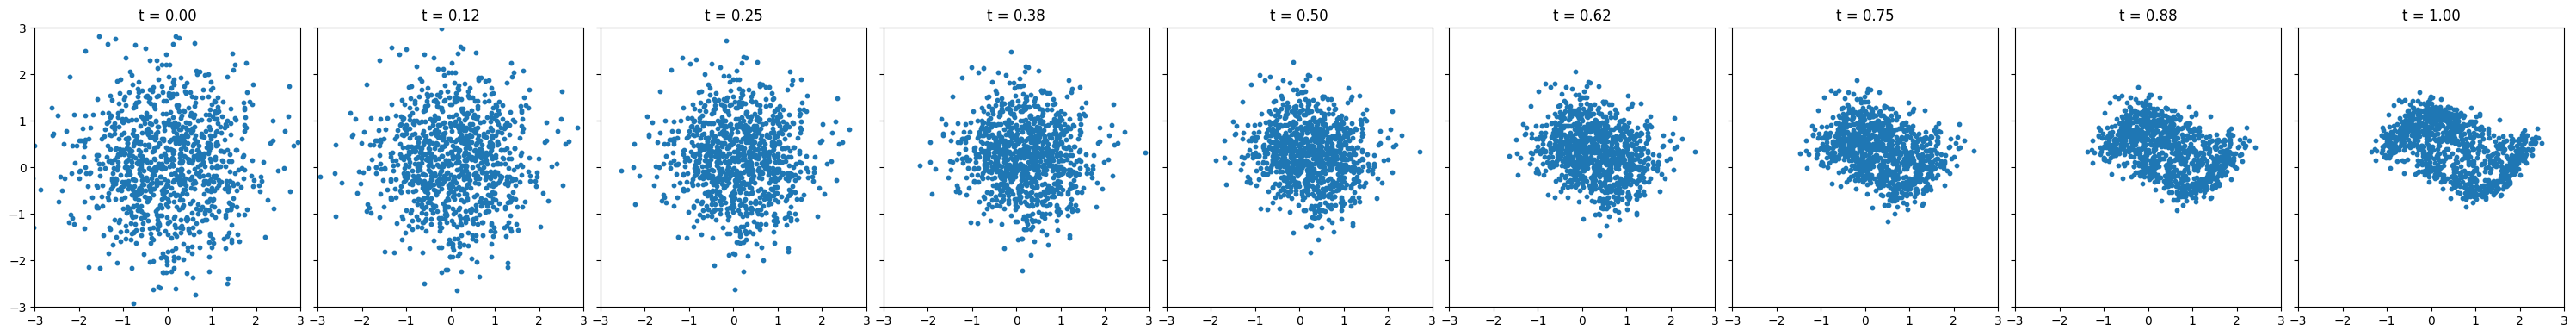

Mean_Field_Flow 模型 Wasserstein-2 距离: 0.456579


In [11]:
x = torch.randn(1000, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

# CPU sampling
mf_flow.cpu()

for i in range(n_steps):
    stats = compute_stats(x)
    stats_batch = stats.unsqueeze(0).expand(x.size(0), -1)
    x = mf_flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1], stats=stats_batch)
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

real_data = make_moons(1000, noise=0.15)[0]          # 返回的是 numpy array
x_np = x.detach().cpu().numpy()                      # 转为 numpy

a = np.ones(1000) / 1000
b = np.ones(1000) / 1000

w2 = np.sqrt(ot.emd2(a, b, ot.dist(real_data, x_np, metric='euclidean')))
print(f"Mean_Field_Flow 模型 Wasserstein-2 距离: {w2:.6f}")